In [1]:
import sys

sys.path.insert(1,"../src/")

from utilities import find_peaks, wideband_pulse, MyPolygonSelector
import warping

In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp
from scipy.ndimage import label

from scipy.special import softmax

In [3]:
%matplotlib widget

In [4]:
from visualization_tools import SelectFromCollection
#from matplotlib.widgets import PolygonSelector

In [5]:
from sklearn.mixture import GaussianMixture

In [6]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [7]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

NPERSEG = 80

NPEAKS = 20

In [8]:
wb_pulse_params = dict(pulse_duration=0.2, fs=SAMPLING_FREQ, bw=200, fc=350, window=sp.windows.tukey)

In [9]:
data1 = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

f = data1['f'].squeeze()
c = data1['soundspeed'].squeeze()
Vg = data1['Vg'][:,:,c == TRUE_SOUNDSPEED,...].squeeze()
source_range = data1['range'][0,0]

In [10]:
df = f[1] - f[0]

#t0 = 0
t0 = source_range*1e3/1500
N = SAMPLING_FREQ/df

In [11]:
X = data1["g"][1, data1["soundspeed"]==TRUE_SOUNDSPEED].squeeze()

In [12]:
X = X  * np.exp(1j*2*np.pi*f*t0);
# x = np.real(np.ifft(X,N) * exp(1i*2*pi*(0:N-1)'*f(1)/SAMPLING_FREQ);

x = np.real(np.fft.ifft(X,int(N)) * np.exp(1j*2*np.pi*np.arange(N)*f[0]/SAMPLING_FREQ))
tx = np.arange(N)/SAMPLING_FREQ + t0

In [13]:
h = wideband_pulse(**wb_pulse_params)

#x = sp.filtfilt(h, 1, x)

## Spectrogram Compared to Mode Curves

In [14]:
[w, t, X] = sp.spectrogram(x, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG-1, 2000)
t = t + t0

w = w[201:502]
X = X[201:502, :]

## Warping

In [62]:
origin_time = 6.81

x_warped, tw, fsw = warping.nonlinear_warping(x[tx>=origin_time], SAMPLING_FREQ, t0)

In [63]:
nperseg = 1500
nfft = 2000
[ww, txw, Xw] = sp.stft(x_warped, fsw, 'hamm', nperseg, nperseg-1, nfft)

In [64]:
normalize01 = lambda x: (x-x.min())/(x.max() - x.min())
logistic = lambda x,c,sigma: 1/(1+np.exp(-(x-c)/sigma))

normpdf = lambda x, m, sigma: np.exp(-(x-m)**2/2/sigma**2)/sigma/np.sqrt(2*np.pi)

In [65]:
Xn = normalize01(np.abs(Xw)**2)
Xw_log = 10*np.log10(np.abs(Xw)**2)

In [66]:
Xn.mean()

np.float64(0.001630787896389304)

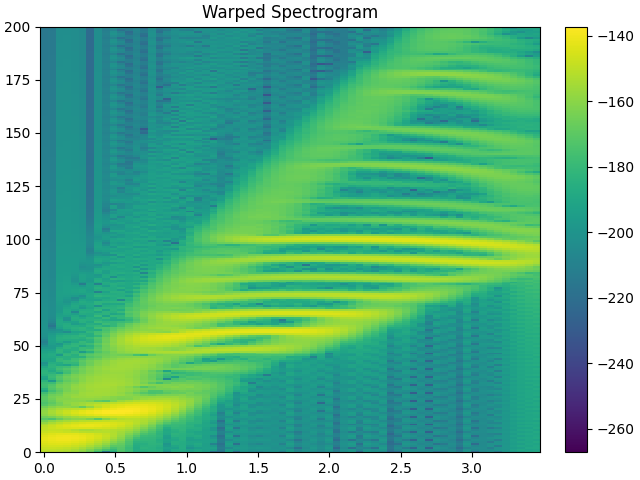

In [68]:
fig, ax = plt.subplots(layout='constrained')

#TT, WW = np.meshgrid(txw, ww)
#cc = ax.scatter(TT.flatten(), WW.flatten())
m1 = ax.pcolormesh(txw[::100], ww, Xw_log[:,::100])

ax.set_ylim([0, 200])

ax.set_title("Warped Spectrogram")

plt.colorbar(m1, ax=ax)

plt.show()

In [49]:
selector = MyPolygonSelector(ax)

In [65]:
selector.select()

In [66]:
TT, WW = np.meshgrid(txw, ww)

In [67]:
nlabels = len(selector.polygons)
x_components = np.empty((nlabels, np.int64(N)))

for i_label in range(nlabels):
    #mask_now = labeled_data == i_label
    mask_now = selector.polygons[i_label].contains_points(np.array([TT.flat, WW.flat]).T).reshape(TT.shape)
    X_comp_now = Xw * mask_now

    xnow = sp.istft(X_comp_now, fsw, 'hamm', nperseg, nperseg-1, nfft)[1]

    x_components[i_label] = warping.inv_nonlinear_warping(xnow, fsw, origin_time, SAMPLING_FREQ, N)[0]

[wc, tc, X_components] = sp.stft(x_components, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG - 1, 2000)

fmask = np.all([wc>=200, wc<=500], 0) 
wc = wc[fmask]    
X_components = X_components[:, fmask, :]


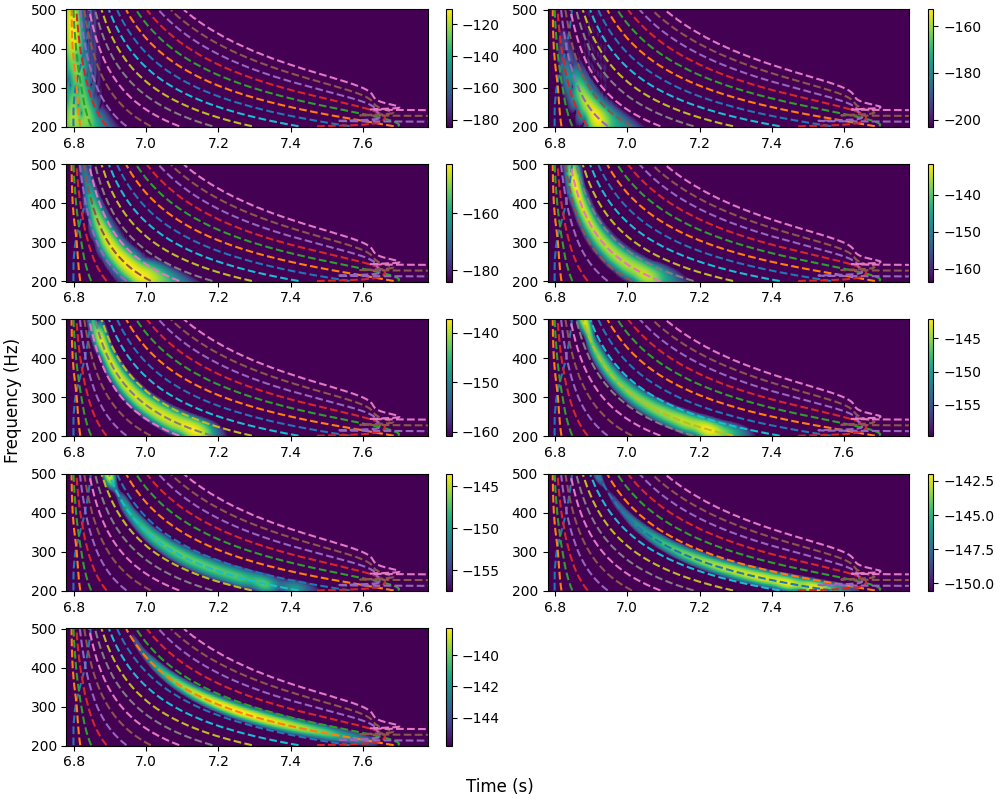

In [68]:
fig = plt.figure(layout='constrained')

vmin, vmax = np.quantile(20*np.log10(np.abs(X_components)), [.9, 1], [1,2])


nc = 2
nr = int(np.ceil(nlabels/2))

for ind in range(nlabels):
    ax = fig.add_subplot(nr, 2, ind + 1)
    m = ax.pcolormesh(tc + origin_time, wc, 20*np.log10(np.abs(X_components[ind])), vmin=vmin[ind], vmax=vmax[ind])
    ax.plot(source_range*1e3/Vg.T, f[1:-1], '--')
    ax.set_xlim(tc[[0,-1]] + origin_time)

    plt.colorbar(m, ax=ax)
fig.set_size_inches([10,8])    
fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')
#fig.savefig('../data/output/figures/timewarping_extracted_components.png', dpi=600)
plt.show()

In [93]:
peaks_components = list()

min_height = np.quantile(np.abs(X_components)**2, .95, [1,2])

for ind, Xc in enumerate(np.abs(X_components)**2):
    peaks_components.append(find_peaks(Xc, wc, tc + origin_time, npeaks=2, min_height = min_height[ind]))


Text(0.5, 0.98, 'Arrival times from unwarped data')

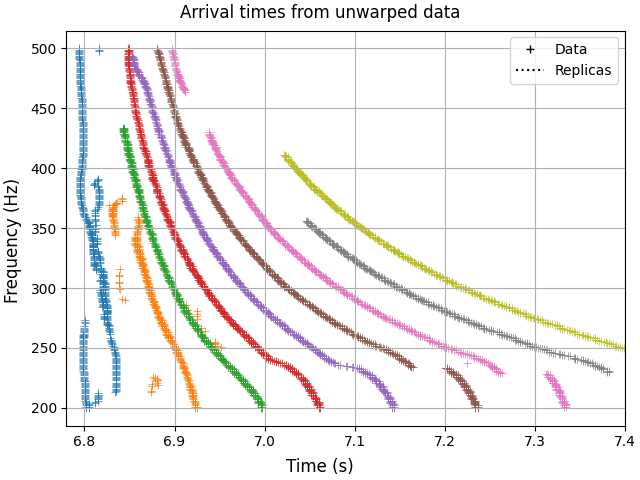

In [75]:
fig, ax = plt.subplots(layout='constrained')

ax.grid()
for p in peaks_components:
    ax.scatter(p[:,0], p[:,1], marker = '+', linewidths=.5)
    
ax.set_xlim([origin_time, 7.4])

ax.plot(0, 350, 'k+', label="Data")
ax.plot(0, 350, 'k:', label="Replicas")

ax.legend()


fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')

fig.suptitle("Arrival times from unwarped data")
#fig.set_size_inches([30,12])    

#fig.savefig('../data/output/figures/timewarping_arrival_times.png', dpi=600)

In [76]:
other_selector = MyPolygonSelector(ax)

In [79]:
other_selector.select()

In [94]:
temp = np.concatenate(peaks_components[:2])
low_modes_peaks = list() 

for a in other_selector.polygons:
    low_modes_peaks.append(temp[a.contains_points(temp), :])
    

In [95]:
peaks_components = low_modes_peaks + peaks_components[2:]

Text(0.5, 0.98, 'Arrival times from unwarped data')

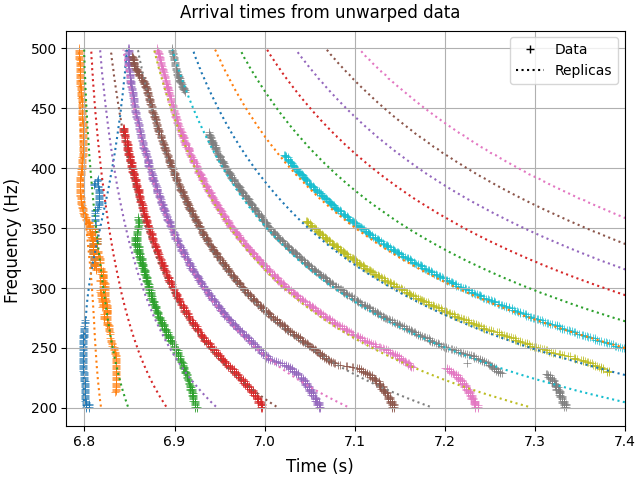

In [96]:
fig, ax = plt.subplots(layout='constrained')

ax.grid()
for p in peaks_components:
    ax.scatter(p[:,0], p[:,1], marker = '+', linewidths=.5)
ax.plot(source_range*1e3/Vg.T, f[1:-1], ':')
ax.set_xlim([origin_time, 7.4])

ax.plot(0, 350, 'k+', label="Data")
ax.plot(0, 350, 'k:', label="Replicas")

ax.legend()


fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')

fig.suptitle("Arrival times from unwarped data")
#fig.set_size_inches([30,12])    

#fig.savefig('../data/output/figures/timewarping_arrival_times.png', dpi=600)

In [97]:
export = {'peaks_coordinates':np.array(peaks_components, dtype=object), 'mode_nos':np.array([1,3,5,6,7,8,9,10,11,12])}

np.savez('../data/output/warping_arrival_times.npz', **export)